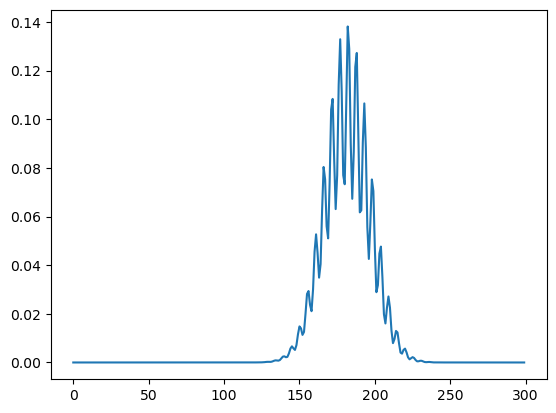

In [17]:
#1d
import matplotlib.pyplot as plt
import numpy as np

L = 300+1
x = np.array([j for j in range(L-1)])
data = np.loadtxt("data/ur_p/H_p_val.csv", delimiter=",", skiprows=1)
y = data[0]

plt.plot(x,y)
plt.show()

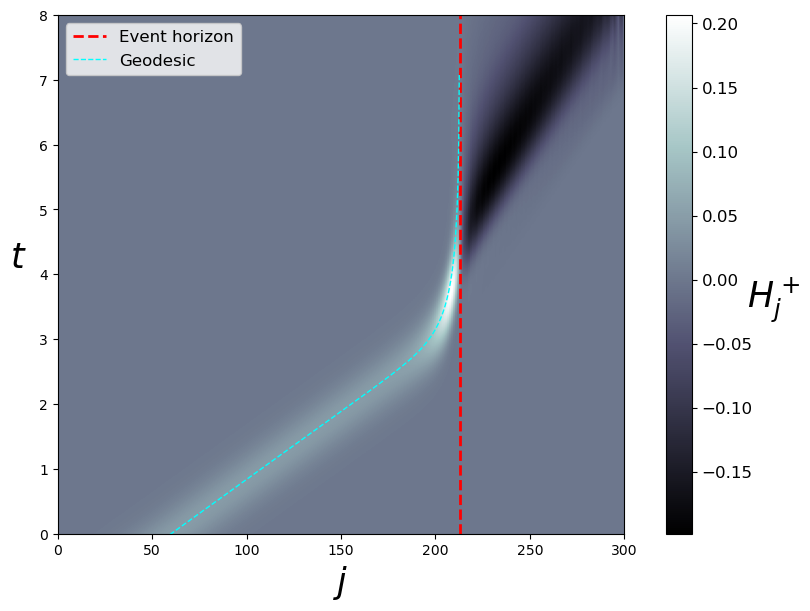

In [43]:
# 2d
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import matplotlib.ticker as ticker

l = 2*np.pi
L = 300
epsilon = l / L
t_f = 8
dt = 0.01*(300/L)



data = np.loadtxt("data/lr_p/H_p_val.csv", delimiter=",", skiprows=1)

# ===== t_f までに制限 =====
nt = int(t_f / dt)
data = data[:nt, :]
# ==========================

ny, nx = data.shape

fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
im = ax.imshow(
    data,
    cmap="bone",
    origin="lower",
    extent=[0, nx, 0, ny * dt],
    aspect="auto",
)
cbar = fig.colorbar(im, ax=ax, label=r"$H_j^-$")
cbar.set_label(r"$H_j^+$", fontsize=25, rotation=0, labelpad=15)
cbar.ax.tick_params(labelsize=12)

ax.axvline(x=0.71*L, color="red", linewidth=2, linestyle="--", label="Event horizon")
ax.set_xlabel(r"$j$", fontsize=25)
ax.set_ylabel(r"$t$", rotation=0, fontsize=25, labelpad=15)
ax.set_ylim(0, t_f)

# ===== geodesic も t_f まで =====
geodesic = np.loadtxt("geodesic/lr_p.csv", delimiter=",", skiprows=1)
x_geodesic = geodesic[:, 0]
t_geodesic = geodesic[:, 1]

mask_t = t_geodesic <= t_f
ax.plot(
    x_geodesic[mask_t] / epsilon,
    t_geodesic[mask_t],
    color="cyan",
    linewidth=1,
    label="Geodesic",
    linestyle="--"
)
# ==============================

plt.legend(fontsize="large",loc="upper left")
plt.savefig("figure/lr_p/H_p.png")
plt.show()


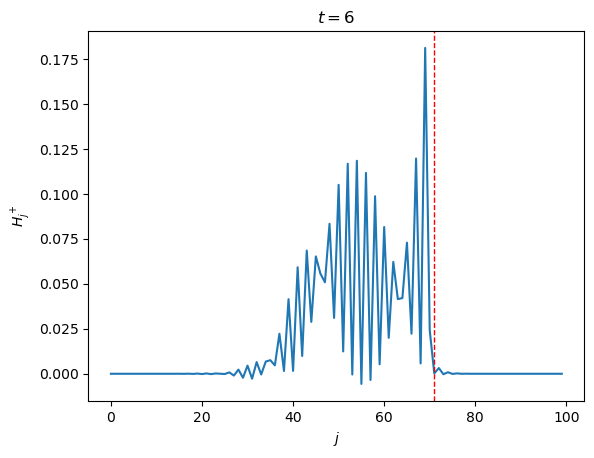

In [38]:
#2d slice
import matplotlib.pyplot as plt
import numpy as np

L = 100
dt = 0.01*(300/L)
t_slice = 6
t_idx = int(t_slice / dt)

x = np.array([j for j in range(L)])
data = np.loadtxt("data/test/H_p_val.csv", delimiter=",", skiprows=1)
y = data[t_idx,:]

plt.title(rf"$t={t_slice}$")
plt.xlabel(r"$j$")
plt.ylabel(r"$H_j^+$")
plt.plot(x,y)
plt.axvline(x=0.71*L, color="red", linewidth=1, linestyle="--")
plt.show()